#**Title:**
#Heart Disease Prediction with Machine Learning
#**Category:**
##Medical Science
#**Objective:**
##To develop a machine learning model that can accurately predict the likelihood of heart disease in individuals based on their clinical and demographic data.
#**Summary:**
##The project starts with data preprocessing and exploration, involving cleaning, visualizing, and analyzing the dataset. Statistical summaries, histograms, and correlation matrices are used to understand the distribution and relationships between features.
##Several classification models are then trained and evaluated, including Logistic Regression, K-Nearest Neighbors, and Random Forest. The performance of these models is assessed using accuracy as the initial metric.

##To improve model performance, hyperparameter tuning is performed using techniques like RandomizedSearchCV and GridSearchCV. The tuned models are further evaluated using a comprehensive set of metrics, including ROC curve and AUC score, confusion matrix, precision, recall, and F1-score.

##**The final results show that Logistic Regression achieves the highest accuracy and performs well across all evaluation metrics. This model demonstrates the potential for accurate heart disease prediction using clinical and demographic data. The insights gained from this project could aid in early diagnosis and intervention for heart disease patients.**

#**Group:** M240105020
##**Dataset sources (URL):** https://drive.google.com/file/d/1q-D2eCTbwMnqIve9Sa8tzss8XOdkd2HV/view?usp=drive_link


#1.0 Install neccesary library and function

In [ ]:
#!pip install sklearn
#Import all libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Inline matplotlib to view inside this notebook directly
%matplotlib inline

#Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score


#2.0 Mount google drive and Import Datasets

In [ ]:
# Install the drive library
!pip install -U -q drive

# Import the drive module
from google.colab import drive

# Mount your Google Drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Ataur_ML_Datasets/heart-Disease.csv")
df.shape

(303, 14)

*There are 14 Features and 303 Samples*

#3.0 Data Preprocessing and Data Exploration (exploratory data analysis or EDA)

The goal here is to find out more about the data

In [ ]:
#show top 10 samples
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
#show last 10 samples
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0
302,57,0,1,130,236,0,0,174,0,0.0,1,1,2,0


In [ ]:
#how many class of one feature or target
df["target"].value_counts()

,count
target,
1,165
0,138


*Positive data 165 and Nagetive data 138*

In [ ]:
#Find out data types and other info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


*13 Features are int and 1 Feature is float*

In [ ]:
#check missing values of all features
df.isna().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


*There is no NULL value in the dataset*

In [ ]:
#It gives a quick summary of key statistical metrics like mean, standard deviation, percentiles
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


<Axes: xlabel='target'>

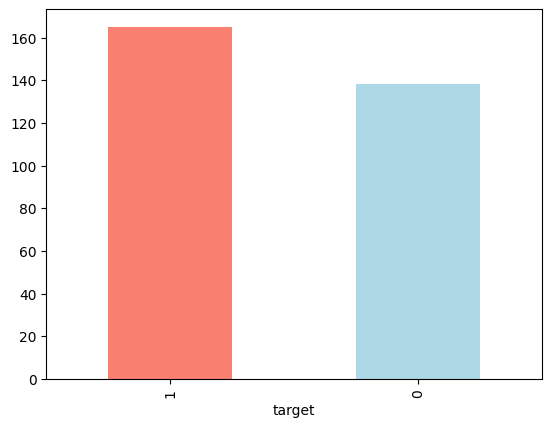

In [ ]:
#bar chart
df["target"].value_counts().plot(kind='bar', color=["salmon","lightblue"])

*In this barchart, we can see that more data samples has heart disease*

###Heart Disease Frequency according to Sex

In [ ]:
df.sex.value_counts()

,count
sex,
1,207
0,96


In [ ]:
#Compare target and sex column
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


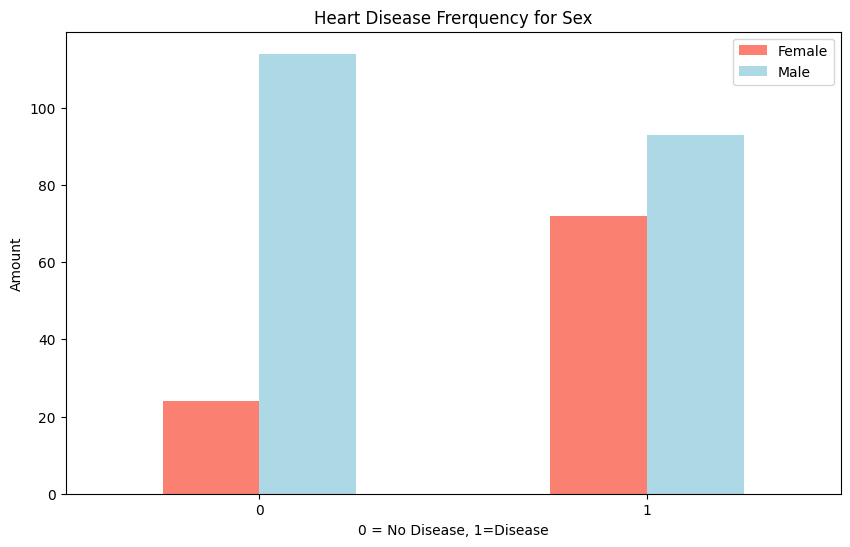

In [ ]:
#We need to find out Female or Male has higher disease rate in this dataset
#Create plot of crosstab to compare this.
pd.crosstab(df.target, df.sex).plot(kind="bar",figsize=(10,6),color=["salmon","lightblue"])
plt.title("Heart Disease Frerquency for Sex")
plt.xlabel("0 = No Disease, 1=Disease")
plt.ylabel("Amount")
plt.legend(["Female","Male"]);
plt.xticks(rotation=0);

*From the barchart above, the frequency of female getting heart disease is higher in this dataset compared to male.*

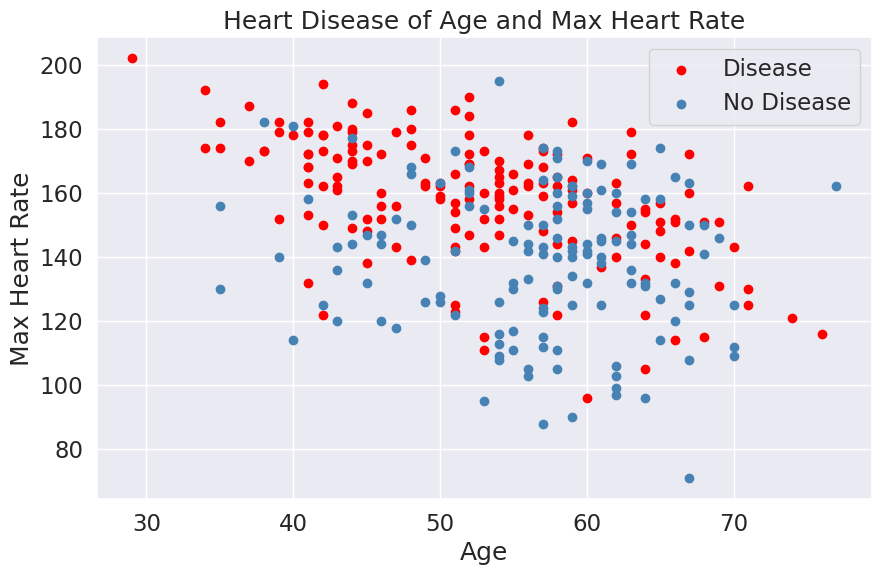

In [ ]:
#Create new figure
plt.figure(figsize=(10,6))

#Scatter with positive examples
plt.scatter(df.age[df.target==1],
           df.thalach[df.target==1],
           c="red")

#Scatter with negative examples
plt.scatter(df.age[df.target==0],
           df.thalach[df.target==0],
           c="steelblue");


plt.title("Heart Disease of Age and Max Heart Rate")
plt.xlabel("Age")
plt.ylabel("Max Heart Rate")
plt.legend(["Disease","No Disease"])

<Axes: ylabel='Frequency'>

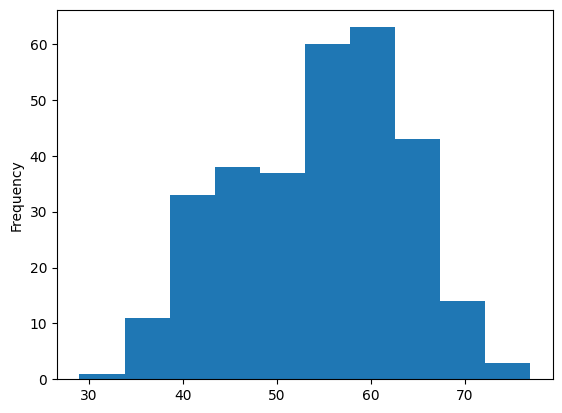

In [ ]:
#Check the distribution of the age column with a histogram
#May check for outliers of the data
df.age.plot.hist()

*In this histogram, we can see that approximately half of the samples age is between 55 to 65 years old. The rest are from 40s to 70s. There are also a few samples for 30-40 and 70 above.*

##Heart Disease Frequency per Chest Pain Type

In [ ]:
pd.crosstab(df.cp,df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


###**cp - chest pain type**

*   Typical angina: chest pain related decrease blood supply to the heart
*   Atypical angina: chest pain not related to heart
*   Non-anginal pain: typically esophageal spasms (non heart related)
*   Asymptomatic: chest pain not showing signs of disease

(array([0, 1, 2, 3]),
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

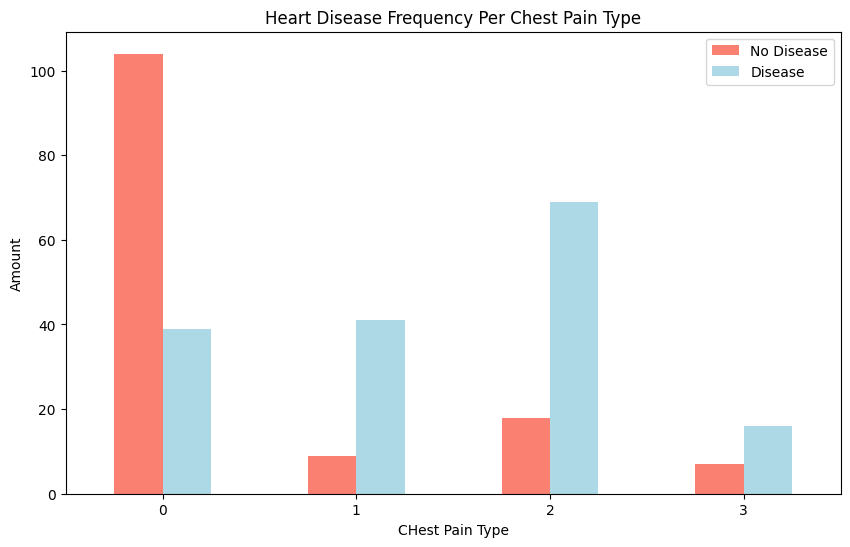

In [ ]:
# Make corsstab visualise
pd.crosstab(df.cp,df.target).plot(kind="bar",figsize=(10,6),color=["salmon","lightblue"])

plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("CHest Pain Type")
plt.ylabel("Amount")
plt.legend(["No Disease","Disease"])
plt.xticks(rotation=0)

Most of the heart disease patients are suffering on the third chest pain type which is non-aginal pain and some of suffering on the first the chest pain type, typical angina and atypical angina. Although the second and third chest pain type is non related to heart, the data shows patients will suffer on those chest pain types. To make a conclusion, we might need to approach some healthcare professions to ask for their opinions.

##Correlation
###Analysing the relationship among the features.

In [ ]:
#Make a correlation matrix
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


(14.5, -0.5)

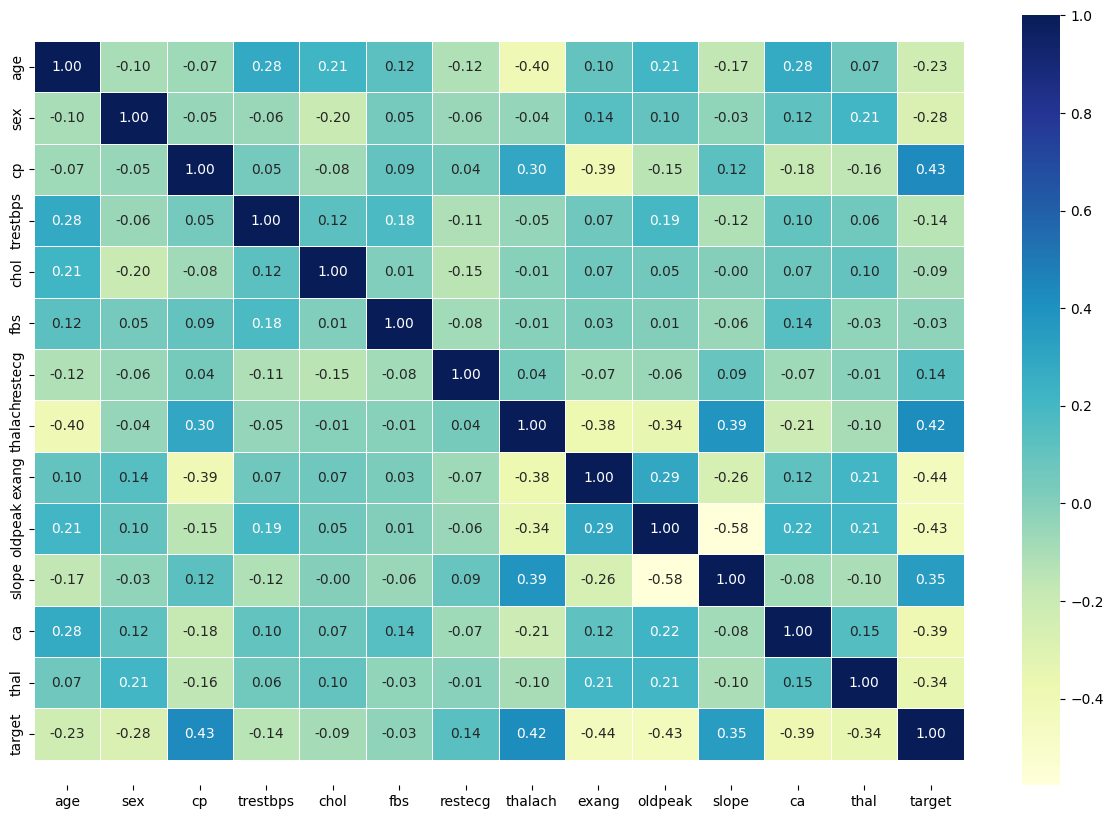

In [ ]:
#Visualise correlation
corr_matrix = df.corr()
fig,ax = plt.subplots(figsize=(15,10))
ax=sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGnBu");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top-0.5)


*   Positive correlation, both variables increase or decrease in same direction
*   Negative correlation, one variable increase and one variable decrease vice versa
*   Result: Chest pain and target have positive correlation -> Higher chest pain level, more targets may get heart disease






#4.0 Modelling
Split data to training and test sets

In [ ]:
# Split data to training and test sets
# Split data into X and y for training features and target variable
X = df.drop("target", axis=1)
y = df["target"]

In [ ]:
#Split data into train and test sets
np.random.seed(42)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split

# Logistic Regression
np.random.seed(42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_reg_score = log_reg.score(X_test, y_test)




/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
print(f"Logistic Regression Test Accuracy: {log_reg_score:.4f}")

Logistic Regression Test Accuracy: 0.8852


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# K-Nearest Neighbors
np.random.seed(42)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_score = knn.score(X_test, y_test)

In [ ]:
print(f"K-Nearest Neighbors Test Accuracy: {knn_score:.4f}")

K-Nearest Neighbors Test Accuracy: 0.6885


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest
np.random.seed(42)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
rf_score = rf.score(X_test, y_test)


In [ ]:
print(f"Random Forest Test Accuracy: {rf_score:.4f}")

Random Forest Test Accuracy: 0.8361


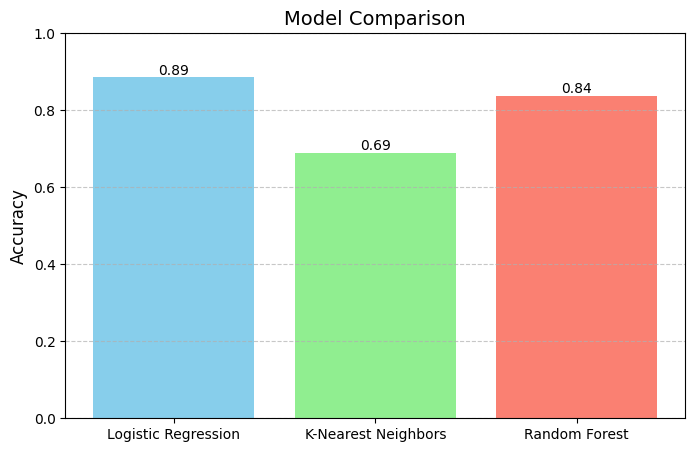

In [ ]:

# Store model names and their scores in a dictionary
model_scores = {
    "Logistic Regression": log_reg_score,
    "K-Nearest Neighbors": knn_score,
    "Random Forest": rf_score
}

# Create a bar plot to compare the results
plt.figure(figsize=(8, 5))
bars = plt.bar(model_scores.keys(), model_scores.values(), color=["skyblue", "lightgreen", "salmon"])

# Add accuracy values on top of each bar
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # X-coordinate
        bar.get_height(),                  # Y-coordinate
        f"{bar.get_height():.2f}",         # Accuracy value with 2 decimal places
        ha="center",                       # Center-align text horizontally
        va="bottom",                       # Position text slightly above the bar
        fontsize=10                        # Font size
    )

# Add titles and labels
plt.title("Model Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(0, 1)  # Ensure y-axis is in the range 0 to 1 for accuracy
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


 Logistic Regression and Random Forest works way more better than KNN.

##Hyperparameter tuning
Ways to tune hyperparameters
*   by hand
*   RandomizedSearchCV
*   GridSearchCV







###Tune By hand

In [ ]:
#Tune knn
train_scores = []
test_scores = []

#list for different values of n-neighbors
neighbors = range(1,21)

#set up knn instance
knn = KNeighborsClassifier()

#loop thru list
for i in neighbors:
    knn.set_params(n_neighbors=i)

    #fit the model
    knn.fit(X_train, y_train)

    # Update the training scores list
    train_scores.append(knn.score(X_train, y_train))

    # Update the test scores list
    test_scores.append(knn.score(X_test, y_test))


In [ ]:
test_scores

[0.6229508196721312,
 0.639344262295082,
 0.6557377049180327,
 0.6721311475409836,
 0.6885245901639344,
 0.7213114754098361,
 0.7049180327868853,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.7540983606557377,
 0.7377049180327869,
 0.7377049180327869,
 0.7377049180327869,
 0.6885245901639344,
 0.7213114754098361,
 0.6885245901639344,
 0.6885245901639344,
 0.7049180327868853,
 0.6557377049180327]

Maximum KNN score on the test data: 75.41%


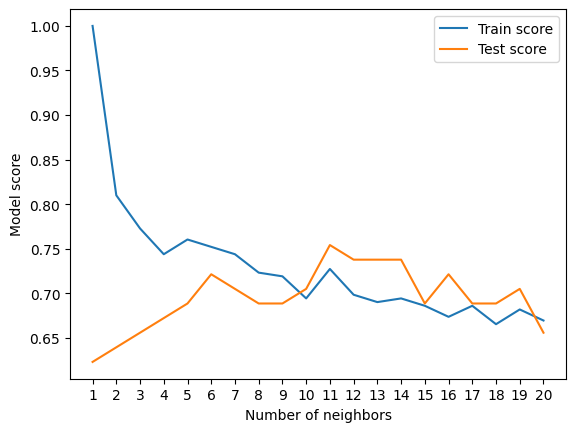

In [ ]:
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

After tuning the parameter for k value, KNN classifier has imporoved but the performance is still lower than Logistic Regression and Random Forest.

###Tuning with RandomizedSearchCV
1.   LogisticRegression()
2.   RandomForestClassifier()

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

#Create a hyperparameter grid for LR
log_reg_grid = {"C": np.logspace(-4,4,20),
                "solver": ["liblinear"]}

#Create a hyperparameter grid for RF
rf_grid = {"n_estimators": np.arange(10,1000,50),
          "max_depth": [None,3,5,10],
          "min_samples_split": np.arange(2,20,2),
          "min_samples_leaf": np.arange(1,20,2)}

In [ ]:
# Tune LogisticRegression

np.random.seed(42)

# Setup random hyperparameter search for LogisticRegression
rs_log_reg = RandomizedSearchCV(LogisticRegression(),
                                param_distributions=log_reg_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)

# Fit random hyperparameter search model for LogisticRegression
rs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [ ]:
rs_log_reg.best_params_

{'solver': 'liblinear', 'C': 0.23357214690901212}

In [ ]:
rs_lr_score = rs_log_reg.score(X_test,y_test)

In [ ]:
#Tune RF

#Set random parameter search for RF
np.random.seed(42)
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                            param_distributions=rf_grid,
                                cv=5,
                                n_iter=20,
                                verbose=True)
#Fit random hyperparameter search model for RF
rs_rf.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestClassifier(), n_iter=20,
                   param_distributions={'max_depth': [None, 3, 5, 10],
                                        'min_samples_leaf': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_split': array([ 2,  4,  6,  8, 10, 12, 14, 16, 18]),
                                        'n_estimators': array([ 10,  60, 110, 160, 210, 260, 310, 360, 410, 460, 510, 560, 610,
       660, 710, 760, 810, 860, 910, 960])},
                   verbose=True)

In [ ]:
#Find best hyperparameter
rs_rf.best_params_

{'n_estimators': 210,
 'min_samples_split': 4,
 'min_samples_leaf': 19,
 'max_depth': 3}

In [ ]:
#Evaluate the randomised search RF model
rs_rf_score =rs_rf.score(X_test, y_test)

In [ ]:
#default model scores
model_scores

{'Logistic Regression': 0.8852459016393442,
 'K-Nearest Neighbors': 0.6885245901639344,
 'Random Forest': 0.8360655737704918}

By using RandomizedSearchCV, the performance of random forest model has improved. But logistic regression model's performance is still higher.

###Tuning with GridSearchCV
1.   LogisticRegression()



In [ ]:
#Different hyperparameters for LR model
log_reg_grid = {"C": np.logspace(-4,4,30),
               "solver": ["liblinear"]}

#Setup grid hyperparameter for LR
gs_log_reg = GridSearchCV(LogisticRegression(),
                         param_grid=log_reg_grid,
                         cv=5,
                         verbose=True)

#Fit into model
gs_log_reg.fit(X_train,y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 1.88739182e-04, 3.56224789e-04, 6.72335754e-04,
       1.26896100e-03, 2.39502662e-03, 4.52035366e-03, 8.53167852e-03,
       1.61026203e-02, 3.03919538e-02, 5.73615251e-02, 1.08263673e-01,
       2.04335972e-01, 3.85662042e-01, 7.27895384e-01, 1.37382380e+00,
       2.59294380e+00, 4.89390092e+00, 9.23670857e+00, 1.74332882e+01,
       3.29034456e+01, 6.21016942e+01, 1.17210230e+02, 2.21221629e+02,
       4.17531894e+02, 7.88046282e+02, 1.48735211e+03, 2.80721620e+03,
       5.29831691e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [ ]:
#check best hyperparameters
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [ ]:
#Evaluate grid search LR model
gs_lr_score = gs_log_reg.score(X_test,y_test)

<Axes: >

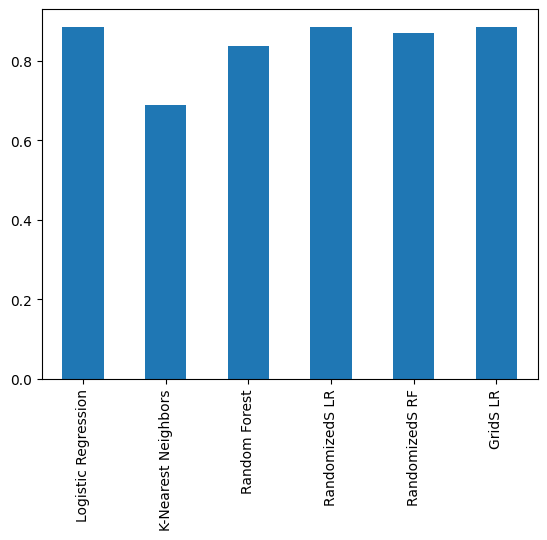

In [ ]:
model_scores.update( [('RandomizedS LR',rs_lr_score),('RandomizedS RF',rs_rf_score),('GridS LR',gs_lr_score)] )
model_compare2 = pd.DataFrame(model_scores, index=["accuracy"])
model_compare2.T.plot.bar(legend=False)

Logistic Regression has the same scores for all of the different hyperparameter tuning own models.

Out of three different classifiers, Logistic Regression has the best performance score during training stage.

##Evaluationg our tuned machine learning classifier, beyond accuracy

*   ROC curve and AUC score
*   Confusion matrix
*   Precision
*   Recall
*   F1-score
*   Classification report

To make comparisons and evaluate our trained model, first we need to make predictions.

In [ ]:
#Make predictions with tuned model
y_preds = gs_log_reg.predict(X_test)

In [ ]:
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

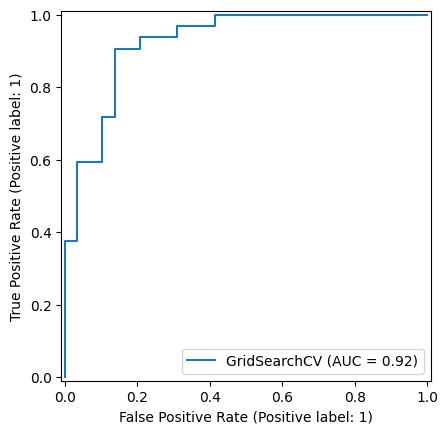

In [ ]:
#Plot ROC curve and calculate AUC metric
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(gs_log_reg, X_test, y_test)

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

#Confusion matrix
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


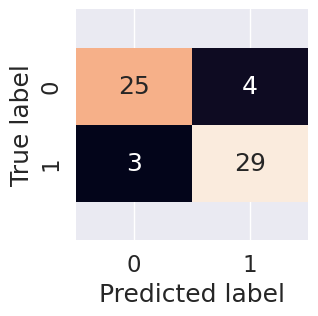

In [ ]:
sns.set(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    """
    Plot a nice looking confusion matrix using Seaborn's heatmap
    """
    fig,ax = plt.subplots(figsize=(3,3))
    ax=sns.heatmap(confusion_matrix(y_test,y_preds),
                  annot=True,
                  cbar=False)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

    bottom, top = ax.get_ylim()
    ax.set_ylim(bottom + 0.5, top - 0.5)

plot_conf_mat(y_test, y_preds)

In [ ]:
#Cross-validated precision, recall and f1-score.
from sklearn.metrics import precision_score, recall_score, f1_score

#Using only one split
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



*Accuracy: The proportion of correct predictions out of all predictions made.

Precision: The proportion of true positive predictions out of all positive predictions made.

Recall: The proportion of true positive predictions out of all actual positive cases.

F1 Score: The harmonic mean of precision and recall, providing a balance between them.*

In [ ]:
#Check best hyperparameters
gs_log_reg.best_params_

{'C': 0.20433597178569418, 'solver': 'liblinear'}

In [ ]:
#Create a new classifier with best parameters
clf = LogisticRegression(C=0.20433597178569418,
                        solver="liblinear")

In [ ]:
#Cross validated accuracy
cv_acc= cross_val_score(clf,
                       X,
                       y,
                       cv=5,
                       scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.86885246, 0.88333333, 0.75      ])

In [ ]:
cv_acc = np.mean(cv_acc)
cv_acc

0.8446994535519124

In [ ]:
#Cross-validated precision
cv_precision= cross_val_score(clf,
                       X,
                       y,
                       cv=5,
                       scoring="precision")
cv_precision = np.mean(cv_precision)
cv_precision

0.8207936507936507

In [ ]:
#Cross-validated recall
cv_recall= cross_val_score(clf,
                       X,
                       y,
                       cv=5,
                       scoring="recall")
cv_recall = np.mean(cv_recall)
cv_recall

0.9212121212121213

In [ ]:
#Cross-validated f1
cv_f1= cross_val_score(clf,
                       X,
                       y,
                       cv=5,
                       scoring="f1")
cv_f1 = np.mean(cv_f1)
cv_f1

0.8673007976269721

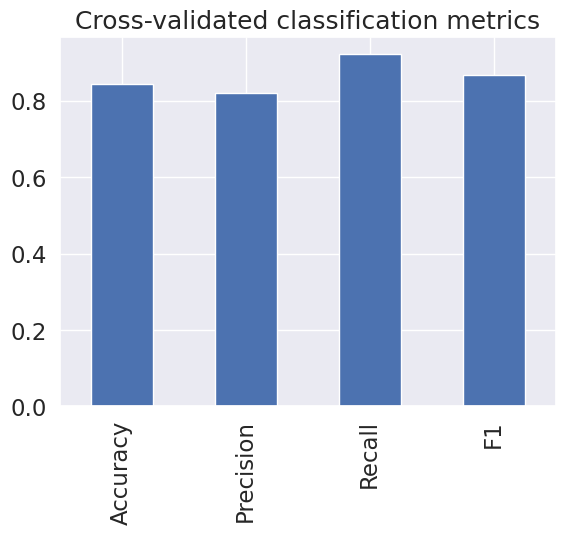

In [ ]:
#Visualise cross-validated metrics
cv_metrics = pd.DataFrame({"Accuracy": cv_acc,
                          "Precision": cv_precision,
                          "Recall": cv_recall,
                          "F1": cv_f1},
                          index=[0])

cv_metrics.T.plot.bar(title="Cross-validated classification metrics",
                      legend=False);

*the performance of a classification model using four different metrics: Accuracy, Precision, Recall, and F1 score. Each bar represents one of these metrics, and they all have values close to or above 0.8, indicating good performance of the model.*